In [1]:
%%capture
%pip install tensorflow-cpu==2.16.2

# Suppress warnings and set environment variables
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'


In [2]:
import numpy as np
from tensorflow.keras.datasets import mnist
import warnings

# Suppress all Python warnings
warnings.filterwarnings('ignore')

# Load the MNIST dataset
(x_train, _), (_, _) = mnist.load_data()

# Normalize the pixel values to the range [-1, 1]
x_train = x_train.astype('float32') / 127.5 - 1.
x_train = np.expand_dims(x_train, axis=-1)

# Print the shape of the data
print(x_train.shape)


(60000, 28, 28, 1)


Building the generator model

In [3]:
from tensorflow.keras.models import Sequential  # Modelo sequencial (camadas empilhadas)
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization, Reshape  # Camadas usadas na rede

# Define the generator model 
def build_generator(): 
    model = Sequential()  # Cria modelo sequencial vazio

    model.add(Dense(256, input_dim=100))  # Entrada: vetor de ruído com 100 dimensões → 256 neurônios
    model.add(LeakyReLU(alpha=0.2))  # Função de ativação que evita neurônios mortos
    model.add(BatchNormalization(momentum=0.8))  # Normaliza os dados para estabilizar o treino

    model.add(Dense(512))  # Expande representação → 512 neurônios
    model.add(LeakyReLU(alpha=0.2))  # Ativação não linear
    model.add(BatchNormalization(momentum=0.8))  # Normalização

    model.add(Dense(1024))  # Expande ainda mais → 1024 neurônios
    model.add(LeakyReLU(alpha=0.2))  # Ativação
    model.add(BatchNormalization(momentum=0.8))  # Normalização

    model.add(Dense(28 * 28 * 1, activation='tanh'))  # Gera vetor com tamanho de imagem (784 valores)
    model.add(Reshape((28, 28, 1)))  # Converte vetor em imagem 28x28 com 1 canal

    return model  # Retorna o modelo gerador

# Build the generator 
generator = build_generator()  # Cria o modelo gerador
generator.summary()  # Mostra arquitetura do modelo

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       803,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,493,520 (5.70 MB)

 Trainable params: 1,489,936 (5.68 MB)

 Non-trainable params: 3,584 (14.00 KB)

Building the discriminator model


In [4]:
from tensorflow.keras.layers import Flatten  # Camada para transformar imagem em vetor
from tensorflow.keras.models import Sequential  # Modelo sequencial
from tensorflow.keras.layers import Dense, LeakyReLU  # Camadas densas e função de ativação

# Define the discriminator model 
def build_discriminator(): 
    model = Sequential()  # Cria modelo sequencial vazio

    model.add(Flatten(input_shape=(28, 28, 1)))  # Converte imagem 28x28 em vetor (784 valores)

    model.add(Dense(512))  # Camada densa com 512 neurônios
    model.add(LeakyReLU(alpha=0.2))  # Ativação que evita neurônios mortos

    model.add(Dense(256))  # Camada densa com 256 neurônios
    model.add(LeakyReLU(alpha=0.2))  # Ativação

    model.add(Dense(1, activation='sigmoid'))  # Saída: probabilidade (real ou fake)

    return model  # Retorna o modelo discriminador

# Build and compile the discriminator 
discriminator = build_discriminator()  # Cria o modelo

discriminator.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])  
# loss → mede erro de classificação (real vs fake)  
# optimizer → ajusta pesos  
# metrics → avalia acurácia

discriminator.summary()  # Mostra arquitetura do modelo

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Building the GAN Model

In [6]:
from tensorflow.keras.layers import Input  # Camada de entrada
from tensorflow.keras.models import Model  # Modelo funcional

# Create the GAN by stacking the generator and the discriminator 
def build_gan(generator, discriminator): 
    discriminator.trainable = False  # Congela o discriminator dentro da GAN (ele não será treinado aqui)

    gan_input = Input(shape=(100,))  # Entrada da GAN: vetor de ruído (100 dimensões)

    generated_image = generator(gan_input)  # Passa o ruído pelo generator → gera imagem fake

    gan_output = discriminator(generated_image)  # Passa a imagem fake pelo discriminator → avalia se é real ou fake

    gan = Model(gan_input, gan_output)  # Cria o modelo GAN completo (ruído → decisão real/fake)

    gan.compile(loss='binary_crossentropy', optimizer='adam')  # Compila a GAN com loss binária

    return gan  # Retorna a GAN

# Build the GAN 
gan = build_gan(generator, discriminator)  # Cria a GAN combinando generator + discriminator

gan.summary()  # Mostra arquitetura da GAN


# Sync discriminator weights from trainable to non-trainable in GAN
gan.layers[2].set_weights(discriminator.get_weights())  # Atualiza os pesos do discriminator dentro da GAN

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 28, 28, 1)      │     1,493,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 1)              │       533,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,027,025 (7.73 MB)

 Trainable params: 1,489,936 (5.68 MB)

 Non-trainable params: 537,089 (2.05 MB)

Training the GAN

In [7]:
# Define and compile the discriminator model
from tensorflow.keras.models import Sequential  # Modelo sequencial (camadas empilhadas)
from tensorflow.keras.layers import Dense, LeakyReLU, Flatten  # Camadas da rede

def build_discriminator():
    model = Sequential()  # Cria modelo vazio

    model.add(Flatten(input_shape=(28, 28, 1)))  # Converte imagem 28x28 em vetor (784)

    model.add(Dense(512))  # Camada com 512 neurônios
    model.add(LeakyReLU(alpha=0.2))  # Ativação que evita neurônios mortos

    model.add(Dense(256))  # Camada com 256 neurônios
    model.add(LeakyReLU(alpha=0.2))  # Ativação

    model.add(Dense(1, activation='sigmoid'))  # Saída: probabilidade (real ou fake)

    return model  # Retorna o modelo

# Build and recompile the discriminator
discriminator = build_discriminator()  # Cria o discriminator

discriminator.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])  
# loss → erro binário (real vs fake)  
# optimizer → ajusta pesos  
# metrics → mede acurácia

discriminator.summary()  # Mostra arquitetura

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Training parameters 

batch_size = 64  # Número de imagens por batch
epochs = 200  # Quantidade de vezes que o treino completo será executado
sample_interval = 10  # Intervalo para exibir progresso

# Adversarial ground truths 
real = np.ones((batch_size, 1))  # Vetor de rótulos "real" (1)
fake = np.zeros((batch_size, 1))  # Vetor de rótulos "fake" (0)

# Training loop 
for epoch in range(epochs):  # Loop principal de treino

    # Train the discriminator 
    idx = np.random.randint(0, x_train.shape[0], batch_size)  # Seleciona imagens reais aleatórias
    real_images = x_train[idx]  # Pega batch de imagens reais

    noise = np.random.normal(0, 1, (batch_size, 100))  # Gera ruído aleatório
    generated_images = generator.predict(noise)  # Generator cria imagens falsas

    d_loss_real = discriminator.train_on_batch(real_images, real)  # Treina discriminator com imagens reais
    d_loss_fake = discriminator.train_on_batch(generated_images, fake)  # Treina com imagens falsas

    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)  # Calcula média das perdas

    # Train the generator 
    noise = np.random.normal(0, 1, (batch_size, 100))  # Novo ruído aleatório
    g_loss = gan.train_on_batch(noise, real)  # Treina generator via GAN (quer que fake seja classificado como real)

    # Print the progress 
    if epoch % sample_interval == 0:  # A cada X épocas
        print(f"{epoch} [D loss: {d_loss[0]}] [D accuracy: {100 * d_loss[1]}%] [G loss: {g_loss}]")  # Exibe métricas

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 
0 [D loss: 1.3115769624710083] [D accuracy: 12.5%] [G loss: 0.6850165128707886]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
10 [D loss: 0.22175204753875732] [D accuracy: 90.11093378067017%] [G loss: 0.25519075989723206]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
20 [D loss: 0.1157886311411857

Assessing the Quality of Generated Images


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


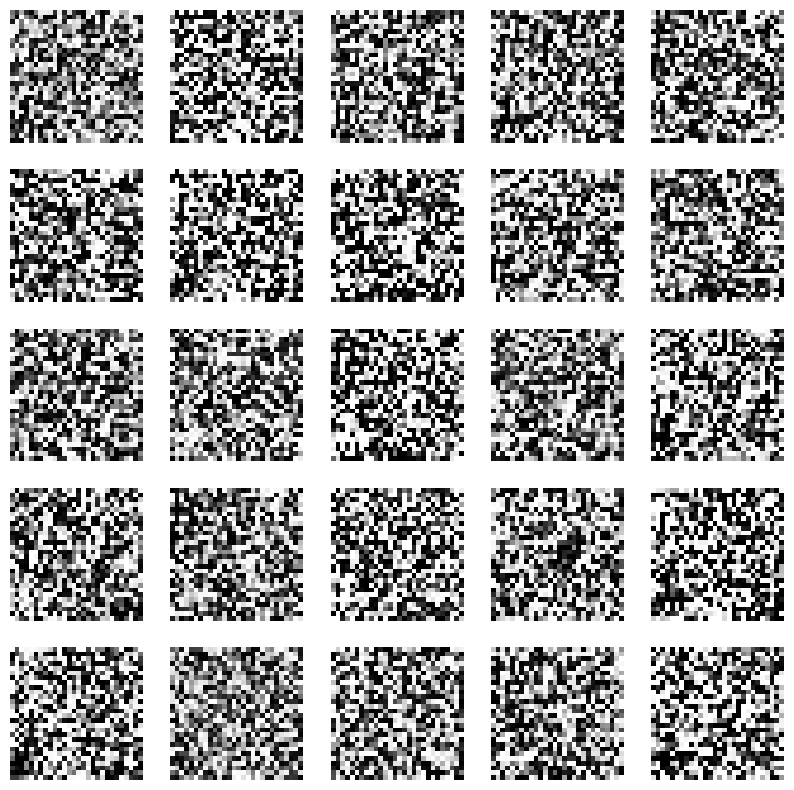

In [9]:
%pip install matplotlib  # Instala a biblioteca matplotlib (usada para visualização)

import matplotlib.pyplot as plt  # Importa a biblioteca de gráficos

def sample_images(generator, epoch, num_images=25): 
    noise = np.random.normal(0, 1, (num_images, 100))  # Gera ruído aleatório para entrada do generator

    generated_images = generator.predict(noise)  # Generator cria imagens falsas a partir do ruído

    generated_images = 0.5 * generated_images + 0.5  # Reescala valores de [-1,1] para [0,1] (necessário para visualizar)

    fig, axs = plt.subplots(5, 5, figsize=(10, 10))  # Cria grid 5x5 para exibir imagens

    count = 0  # Contador de imagens

    for i in range(5):  # Loop nas linhas
        for j in range(5):  # Loop nas colunas
            axs[i, j].imshow(generated_images[count, :, :, 0], cmap='gray')  # Mostra imagem gerada
            axs[i, j].axis('off')  # Remove eixos
            count += 1  # Avança para próxima imagem

    plt.show()  # Exibe todas as imagens

# Sample images at the end of training 
sample_images(generator, epochs)  # Gera e mostra imagens após o treino

In [10]:
# Calculate and print the discriminator accuracy on real vs. fake images
noise = np.random.normal(0, 1, (batch_size, 100))
generated_images = generator.predict(noise)

# Evaluate the discriminator on real images
real_images = x_train[np.random.randint(0, x_train.shape[0], batch_size)]
d_loss_real = discriminator.evaluate(real_images, np.ones((batch_size, 1)), verbose=0)

# Evaluate the discriminator on fake images
d_loss_fake = discriminator.evaluate(generated_images, np.zeros((batch_size, 1)), verbose=0)

print(f"Discriminator Accuracy on Real Images: {d_loss_real[1] * 100:.2f}%")
print(f"Discriminator Accuracy on Fake Images: {d_loss_fake[1] * 100:.2f}%")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Discriminator Accuracy on Real Images: 100.00%
Discriminator Accuracy on Fake Images: 100.00%
